In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class GeneralizedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, orthonormal=False):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.total_dim = d * s
        
        # Add a batch dimension: (batch_size, ds, ds)
        self.raw_u = nn.Parameter(torch.randn(
            self.batch_size, self.total_dim, self.total_dim, 
            dtype=torch.float32 if orthonormal else torch.complex64
        ))

    def get_unitary(self):
        # Batch-wise adjoint and matrix exponential
        X = self.raw_u - self.raw_u.adjoint() 
        return torch.matrix_exp(X)
        # can also do Cayley Transform for orthonormal case, but matrix exponential is more general and works for unistochastic as well.

    def forward(self):
        U = self.get_unitary()
        
        # Reshape to (batch, d, s, d, s) -> (batch, d, d, s, s)
        blocks = U.view(self.batch_size, self.d, self.s, self.d, self.s).permute(0, 1, 3, 2, 4)
        
        # Sum across the internal s x s blocks for the whole batch
        bistochastic_matrices = torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / self.s
        
        return bistochastic_matrices

In [ ]:
class AveragedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, free_s=False):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.free_s = free_s
    
        self.raw_u = nn.Parameter(torch.randn(
            self.batch_size, self.s, self.d, self.d, 
            dtype=torch.float32
        ))
        
        if free_s:
            self.s_param = nn.Parameter(torch.randn(self.s))
        
    def get_unitary(self):
        # Batch-wise adjoint and cayley transform using solve
        X = self.raw_u - self.raw_u.transpose(-2, -1)
        I = torch.eye(self.d, device=X.device).expand_as(X)
        return torch.linalg.solve(I - 0.5 * X, I + 0.5 * X)
    
    def forward(self):
        U = self.get_unitary()
        
        if self.free_s:
            # map learned s_param to values between 0 and 1 that sum to 1 using sigmoid and normalization
            sigmoid_s = torch.sigmoid(self.s_param)
            prefactors = sigmoid_s / sigmoid_s.sum()
        
        # take squared of U
        u_squared = torch.abs(U) ** 2
        
        # average over s
        if self.free_s:
            # print("shapes", u_squared.shape, prefactors.shape)
            s_avg = torch.einsum('bsot, s -> bot', u_squared, prefactors)
        else:
            s_avg = u_squared.sum(dim=1) / self.s
        
        return s_avg

In [ ]:
def optimize_to_target_eigenvalue_batched(targets_complex, d, s, steps=100, orthonormal=False, same_inits=False, averaged_unistochastic_test=False, free_s=False):
    batch_size = len(targets_complex)
    if not averaged_unistochastic_test:
        model = GeneralizedUnistochastic(d, s, batch_size=batch_size, orthonormal=orthonormal)
    else:
        model = AveragedUnistochastic(d, s, batch_size=batch_size, free_s=free_s)
    
    if same_inits:
        with torch.no_grad():
            model.raw_u.copy_(model.raw_u[0:1].expand(batch_size, -1, -1))
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    
    # targets shape: (batch_size, 1) for broadcasting
    target_real = torch.tensor(targets_complex.real, dtype=torch.float32).unsqueeze(1)
    target_imag = torch.tensor(targets_complex.imag, dtype=torch.float32).unsqueeze(1)
    
    # Store results for all targets in the batch
    # all_eigs_history: (steps, batch_size, d)
    all_eigs_history = torch.zeros((steps, batch_size, d), dtype=torch.complex64)
    
    for idx in range(steps):
        optimizer.zero_grad()
        B = model() # B is (batch_size, d, d)
        
        eigs = torch.linalg.eigvals(B) # eigs is (batch_size, d)
        all_eigs_history[idx] = eigs
        
        # Distance calculation using broadcasting
        # (batch_size, d) - (batch_size, 1) -> (batch_size, d)
        dist_sq = (eigs.real - target_real)**2 + (eigs.imag - target_imag)**2
        
        # Loss: minimize the distance of the *closest* eigenvalue per target, 
        # then sum across the batch to get a single scalar for .backward()
        loss = torch.min(dist_sq, dim=1)[0].sum()
        
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        final_B = model()
        final_eigs = torch.linalg.eigvals(final_B).numpy()
        return final_eigs, all_eigs_history.numpy()

# --- Execution Loop ---

n_points = 10000
targets = []
while len(targets) < n_points:
    x, y = np.random.uniform(-1, 1, 2)
    # if x**2 + y**2 <= 1:
    targets.append(complex(x, y))
    
batch_size = 100 # Adjust based on your RAM/CPU

from dataclasses import dataclass
@dataclass(frozen=True)
class OptimizationQuestion:
    s: int
    d: int
    orthonormal: bool
    same_inits: bool = False
    _garbage: int = 0 # To ensure uniqueness in dict keys if needed
    
    averaged_unistochastic_test: bool = False # Whether to use the AveragedUnistochastic model instead of GeneralizedUnistochastic
    free_s: bool = False # Whether to allow s to be a free parameter in the AveragedUnistochastic model (only relevant if averaged_unistochastic_test is True)
    
    def title(self):
        ortho_str = "Orthonormal" if self.orthonormal else "General"
        if self.averaged_unistochastic_test:
            free_s_str = "Free s" if self.free_s else "Fixed s"
            return f"Averaged Opt (s={self.s}, {free_s_str})"
        return f"{ortho_str} Opt (s={self.s})"
    
results = {
    OptimizationQuestion(d=3, s=1, orthonormal=True, averaged_unistochastic_test=False, free_s=False): [],
    OptimizationQuestion(d=3, s=2, orthonormal=True, averaged_unistochastic_test=False, free_s=False): [],    
}

from tqdm import tqdm

for result_key in results.keys():
    print(f"Running optimization for: {result_key}")
    # fix seed
    np.random.seed(42)
    torch.manual_seed(42)
    # Process in chunks
    for i in tqdm(range(0, n_points, batch_size)):
        batch_targets = np.array(targets[i : i + batch_size])
        
        # Batch optimization
        res_opt_3, mats_opt_3 = optimize_to_target_eigenvalue_batched(batch_targets, result_key.d, result_key.s, orthonormal=result_key.orthonormal, same_inits=result_key.same_inits, averaged_unistochastic_test=result_key.averaged_unistochastic_test, free_s=result_key.free_s)
        
        # Flatten results to match your original output format
        # res_opt_3 is (batch, d), mats_opt_3 is (steps, batch, d)
        results[result_key].extend(res_opt_3.flatten())
        
        # Your original loop logic: for every target and every step, add every eigenvalue
        # This creates the "dense" scatter plot in your results
        for step_idx in range(mats_opt_3.shape[0]):
            results[result_key].extend(mats_opt_3[step_idx].flatten())

Running optimization for: OptimizationQuestion(s=1, d=3, orthonormal=True, same_inits=False, _garbage=0, averaged_unistochastic_test=True, free_s=True)


100%|██████████| 100/100 [00:13<00:00,  7.37it/s]


Running optimization for: OptimizationQuestion(s=2, d=3, orthonormal=True, same_inits=False, _garbage=0, averaged_unistochastic_test=True, free_s=True)


100%|██████████| 100/100 [00:14<00:00,  6.71it/s]


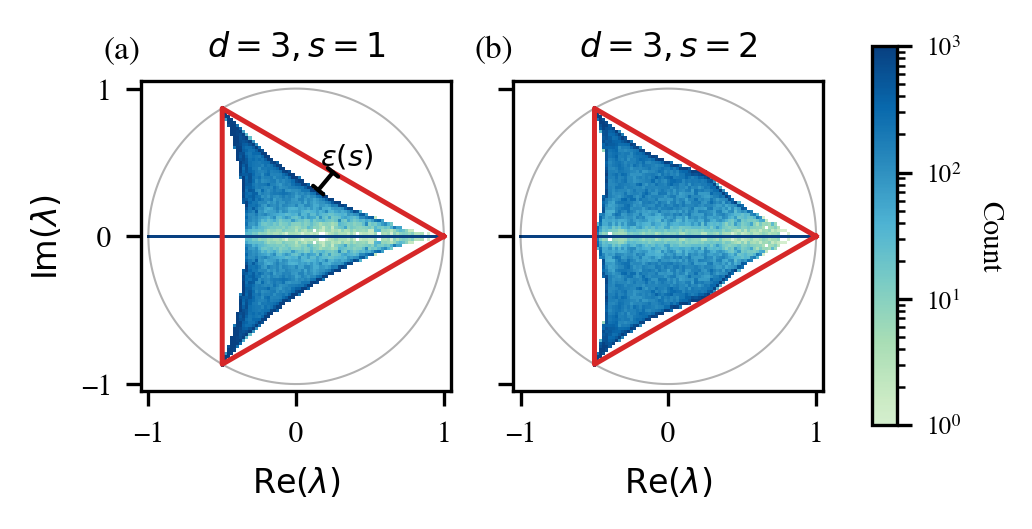

In [ ]:
# FIGURE 3
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import FixedLocator

COLUMN_WIDTH = 3.25 
FONT_SIZE = 8        
TICK_SIZE = 7

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times", "Palatino", "serif"],
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE,
    "figure.titlesize": FONT_SIZE + 2,
})

def plot_paper_ready_figure(results):
    fig, axes = plt.subplots(1, 2, figsize=(COLUMN_WIDTH, 3.8/1.9), sharex=True, sharey=True, dpi=300)
    axes = axes.flatten()
    
    theta = np.linspace(0, 2*np.pi, 200)
    panel_labels = ['(a)', '(b)']
    
    boundaries = {
        3: ([1, np.cos(2*np.pi/3), np.cos(4*np.pi/3), 1], 
            [0, np.sin(2*np.pi/3), np.sin(4*np.pi/3), 0], 'tab:red'),
    }

    last_h = None
    
    for i, (reskey, data) in enumerate(results.items()):
        ax = axes[i]
        data = np.array(data)
        
        # custom cmap starting from GnBu but trimming the lightest colors to avoid washed-out bins
        cmap = colors.LinearSegmentedColormap.from_list("custom_gnbu", plt.cm.GnBu(np.linspace(0.2, 1, 256)))
        
        h = ax.hist2d(
            data.real, data.imag, 
            bins=101, 
            cmap=cmap, 
            cmin=1, 
            range=[[-1.05, 1.05], [-1.05, 1.05]], 
            norm=colors.LogNorm(vmin=1, vmax=1000)
        )
        # rasterize
        h[3].set_rasterized(True)
        last_h = h[3]
        
        # Reference Unit Circle
        ax.plot(np.cos(theta), np.sin(theta), color='k', alpha=0.3, linewidth=0.5, zorder=1)
        
        # Boundaries
        # if reskey.d > 2:
        bx, by, bcol = boundaries[3]
        ax.plot(bx, by, color=bcol, alpha=1.0, zorder=2, linewidth=1.2)
        # if reskey.d > 3:
        #     sx, sy, bcol = boundaries[4]
        #     ax.plot(sx, sy, color=bcol, alpha=1.0, zorder=2, linewidth=1.2)

        # Panel Labeling (a, b, c, d)
        # Placed at top-left in axis coordinates
        ax.text(0, 1.15, panel_labels[i], transform=ax.transAxes, 
                fontsize=FONT_SIZE, fontweight='bold', va='top', ha='right')

        ax.set_aspect('equal')
        ax.xaxis.set_major_locator(FixedLocator([-1, 0, 1]))
        ax.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
        ax.set_title(rf"$d={reskey.d}, s={reskey.s}$", pad=6)

    # Labels for outer plots
    for ax in axes: ax.set_xlabel(r"$\mathrm{Re}(\lambda)$")
    for ax in axes[::2]: ax.set_ylabel(r"$\mathrm{Im}(\lambda)$")
    
    ax = axes[0]  # Annotate on the first subplot for demonstration
    p1 = (0.5*1 + 0.5*np.cos(2*np.pi/3),
          0.5*0 + 0.5*np.sin(2*np.pi/3))  # Example points for epsilon annotation

    delta = 0.1
    p2 = (p1[0]- delta, p1[1]-1.2*delta)  # Move left by delta to create a horizontal epsilon
    midpoint = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
    
    # The Arrow (Bar to Bar)
    ax.annotate('', xy=p2, xytext=p1, 
                arrowprops=dict(arrowstyle='|-|, widthA=0.2, widthB=0.2', 
                                color='k', linewidth=1.0, shrinkA=0,  # Remove padding at p1
                shrinkB=0))   # Remove padding at p2))

    # The Label (Centered at midpoint)
    # Removing the offset points and using alignment often feels more stable
    ax.text(midpoint[0] - 0.04, midpoint[1] + 0.05*3.2, "$\\epsilon(s)$",
            fontsize=7, ha='left', va='center', color='k')

    # Layout adjustment
    # Note: hspace adjusted to 0.4 to prevent panel labels from hitting the plot above
    plt.subplots_adjust(left=0.15, right=0.85, bottom=0.12, top=0.88, wspace=0.2, hspace=-0.1)
    
    # Colorbar
    cbar_ax = fig.add_axes([0.9, 0.185, 0.025, 0.632]) 
    cbar = fig.colorbar(last_h, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label('Count', rotation=270, labelpad=10, size=7)

    # plt.savefig("spectra_numerics_d_eq_3_ours.pdf", bbox_inches='tight')
    # plt.savefig("spectra_numerics_d_eq_3_ours_avg.pdf", bbox_inches='tight')
    plt.show()

plot_paper_ready_figure(results)

# Other Methods

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import itertools

class GeneralizedKromHC(nn.Module):
    def __init__(self, num_factors, N=3, batch_size=1):
        super().__init__()
        self.num_factors = num_factors
        self.N = N
        self.batch_size = batch_size
        
        # Precompute all N! permutation matrices
        perms = list(itertools.permutations(range(N)))
        self.num_perms = len(perms)
        
        perm_mats = torch.zeros((self.num_perms, N, N))
        for i, p in enumerate(perms):
            for row, col in enumerate(p):
                perm_mats[i, row, col] = 1.0
        self.register_buffer('perm_mats', perm_mats)

        # Logits for the convex combination
        self.coeffs = nn.Parameter(torch.randn(batch_size, num_factors, self.num_perms))

    def forward(self):
        weights = F.softmax(self.coeffs, dim=-1) 
        
        # Build factor matrices: (Batch, Num_Factors, N, N)
        factor_mats = (weights.view(self.batch_size, self.num_factors, self.num_perms, 1, 1) * self.perm_mats.view(1, 1, self.num_perms, self.N, self.N)).sum(dim=2)
        
        res = factor_mats[:, 0, :, :]
        
        for k in range(1, self.num_factors):
            mat = factor_mats[:, k, :, :]
            curr_dim = res.shape[1]
            
            res_expanded = res.view(self.batch_size, curr_dim, 1, curr_dim, 1)
            mat_expanded = mat.view(self.batch_size, 1, self.N, 1, self.N)
            
            res = (res_expanded * mat_expanded).reshape(
                self.batch_size, curr_dim * self.N, curr_dim * self.N
            )
        return res

def optimize_spectrum(targets_complex, num_factors, N, steps=250):
    batch_size = len(targets_complex)
    model = GeneralizedKromHC(num_factors, N, batch_size=batch_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.08)
    
    target_tensor = torch.tensor(targets_complex, dtype=torch.complex64).unsqueeze(1)
    history = torch.zeros((steps, N*num_factors*batch_size), dtype=torch.complex64)
    
    for idx in range(steps):
        optimizer.zero_grad()
        B = model() 
        eigs = torch.linalg.eigvals(B)
        
        # Distance to the closest eigenvalue in the Kronecker product
        dist_sq = torch.abs(eigs - target_tensor)**2
        loss = torch.min(dist_sq, dim=1)[0].mean()
        
        loss.backward()
        optimizer.step()
        
        history[idx, :] = eigs.flatten()
        
    return history.detach().cpu().numpy()

In [ ]:
def optimize_spectrum(targets_complex, d, s, steps=250):
    batch_size = len(targets_complex)
    model = ScalableBlockUnistochastic(d, s, batch_size=batch_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.08)
    
    target_tensor = torch.tensor(targets_complex, dtype=torch.complex64).unsqueeze(1)
    history = torch.zeros((steps, N*num_factors*batch_size), dtype=torch.complex64)
    
    for idx in range(steps):
        optimizer.zero_grad()
        B = model() 
        eigs = torch.linalg.eigvals(B)
        
        # Distance to the closest eigenvalue in the Kronecker product
        dist_sq = torch.abs(eigs - target_tensor)**2
        loss = torch.min(dist_sq, dim=1)[0].mean()
        
        loss.backward()
        optimizer.step()
        
        history[idx, :] = eigs.flatten()
        
    return history.detach().cpu().numpy()

In [45]:
class Sinkhorn(nn.Module):
    def __init__(self, d, batch_size=1, iters=20, init=torch.randn):
        super().__init__()
        self.d = d
        self.batch_size = batch_size
        self.iters = iters
        
        self.log_alpha = nn.Parameter(init(batch_size, d, d))
        # initialize log_alpha to 100*Uniform
        self.log_alpha.data.uniform_(-1, 1).mul_(100)

    def sinkhorn_knopps(self, log_alpha):
        for _ in range(self.iters):
            log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)
            log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-2, keepdim=True)
        
        return log_alpha.exp()

    def forward(self):
        bistochastic_matrices = self.sinkhorn_knopps(self.log_alpha)
        return bistochastic_matrices

class SinkhornLinear(nn.Module):
    def __init__(self, d, batch_size=1, iters=20, epsilon=1e-12):
        super().__init__()
        self.d = d
        self.batch_size = batch_size
        self.iters = iters
        self.epsilon = epsilon  # Safeguard against division by zero
        
        # Initialize weights. We use exponential or positive values 
        # because Sinkhorn requires non-negative entries.
        self.W = nn.Parameter(torch.rand(batch_size, d, d))

    def forward(self):
        # Ensure non-negativity (M = abs(M) or M = relu(M))
        # Using abs() as in your snippet
        M = torch.abs(self.W)
        
        for _ in range(self.iters):
            # Row normalization
            # We add epsilon to prevent 0/0 = NaN
            M = M / (M.sum(dim=-1, keepdim=True) + self.epsilon)
            
            # Column normalization
            M = M / (M.sum(dim=-2, keepdim=True) + self.epsilon)
            
        return M    

def optimize_mHC_spectrum(targets_complex, N, max_sk_iters, steps=250):
    batch_size = len(targets_complex)
    # model = mHC(N, batch_size=batch_size, max_sk_iters=max_sk_iters)
    model = Sinkhorn(N, batch_size=batch_size, iters=max_sk_iters)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.08)
    
    target_tensor = torch.tensor(targets_complex, dtype=torch.complex64).unsqueeze(1)
    history = torch.zeros((steps, N*batch_size), dtype=torch.complex64)
    
    for idx in range(steps):
        optimizer.zero_grad()
        B = model()
        jitter = torch.randn_like(B) * 1e-6
        eigs = torch.linalg.eigvals(B + jitter)
        
        # Distance to the closest eigenvalue in the Kronecker product
        dist_sq = torch.abs(eigs - target_tensor)**2
        loss = torch.min(dist_sq, dim=1)[0].mean()
        
        loss.backward()
        optimizer.step()
        
        history[idx, :] = eigs.flatten()
        
    return history.detach().cpu().numpy()

In [35]:
from dataclasses import dataclass
@dataclass(frozen=True)
class CompareLabel:
    label:str
    d:int
    s: int=1
    
results_compare = {}

N = 4
nf = 1

num_factors_to_test = [1]
n_points = 10_000

np.random.seed(42)
targets = np.array([complex(np.random.uniform(-1, 1), np.random.uniform(-1, 1)) for _ in range(n_points)])

final_eigs = optimize_spectrum(targets, nf, N)
data = final_eigs.flatten()

results_compare[CompareLabel(label='mHC-lite', d=N)] = data

In [36]:
results_compare[CompareLabel(label='KromHC, $i_k=2$', d=4)] = optimize_spectrum(targets, 2, 2).flatten()
results_compare[CompareLabel(label='mHC', d=4)] = optimize_mHC_spectrum(targets, 4, 10).flatten()

In [37]:
results = {
    OptimizationQuestion(d=4, s=1, orthonormal=True, averaged_unistochastic_test=False, free_s=False): [],
    OptimizationQuestion(d=4, s=2, orthonormal=True, averaged_unistochastic_test=False, free_s=False): [],
}

from tqdm import tqdm

for result_key in results.keys():
    print(f"Running optimization for: {result_key}")
    # fix seed
    np.random.seed(42)
    torch.manual_seed(42)
    # Process in chunks
    for i in tqdm(range(0, n_points, batch_size)):
        batch_targets = np.array(targets[i : i + batch_size])
        
        # Batch optimization
        res_opt_3, mats_opt_3 = optimize_to_target_eigenvalue_batched(batch_targets, result_key.d, result_key.s, orthonormal=result_key.orthonormal, same_inits=result_key.same_inits, averaged_unistochastic_test=result_key.averaged_unistochastic_test, free_s=result_key.free_s)
        
        # Flatten results to match your original output format
        # res_opt_3 is (batch, d), mats_opt_3 is (steps, batch, d)
        results[result_key].extend(res_opt_3.flatten())
        
        # Your original loop logic: for every target and every step, add every eigenvalue
        # This creates the "dense" scatter plot in your results
        for step_idx in range(mats_opt_3.shape[0]):
            results[result_key].extend(mats_opt_3[step_idx].flatten())
            
results_compare = {**results_compare, **results}

Running optimization for: OptimizationQuestion(s=1, d=4, orthonormal=True, same_inits=False, _garbage=0, averaged_unistochastic_test=False, free_s=False)


100%|██████████| 25/25 [00:17<00:00,  1.47it/s]


Running optimization for: OptimizationQuestion(s=2, d=4, orthonormal=True, same_inits=False, _garbage=0, averaged_unistochastic_test=False, free_s=False)


100%|██████████| 25/25 [00:38<00:00,  1.56s/it]


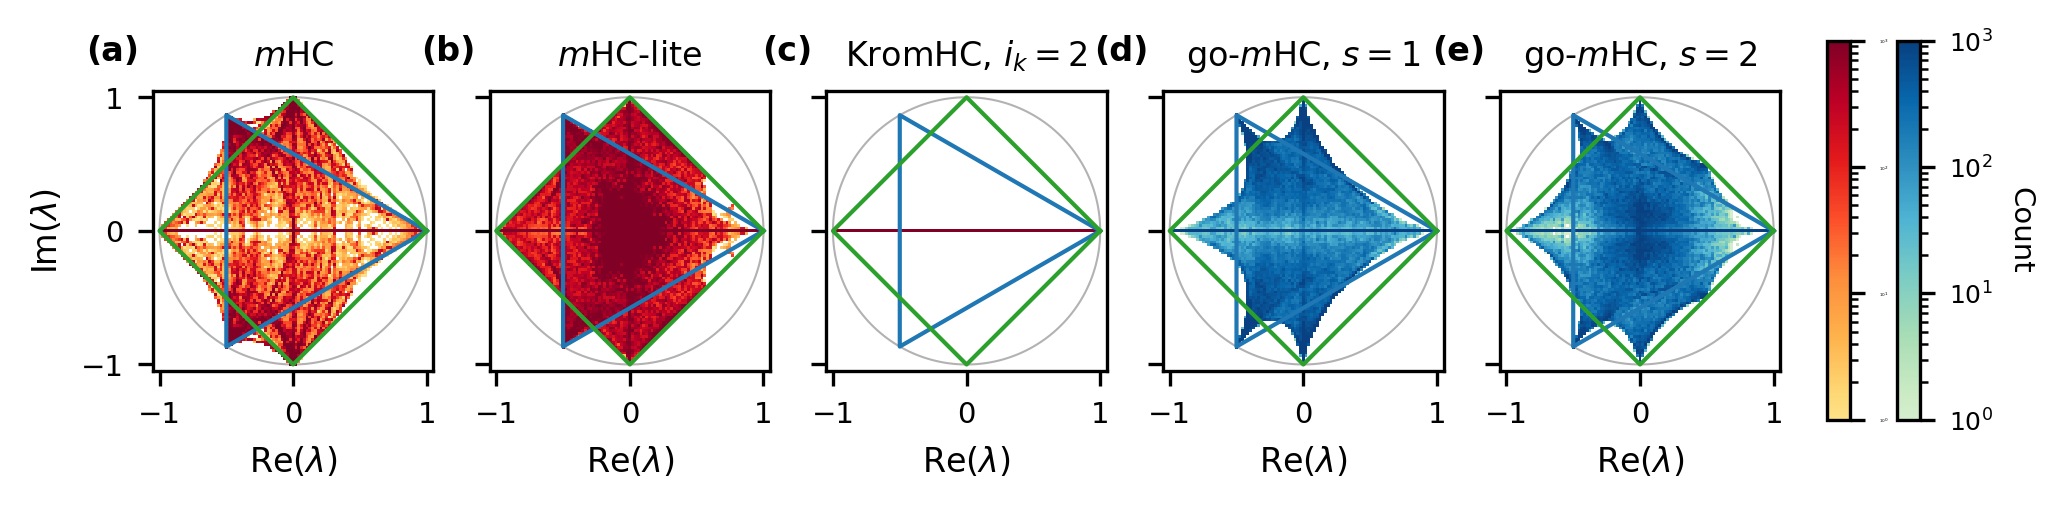

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import FixedLocator

COLUMN_WIDTH = 7.75 
FONT_SIZE = 8
TICK_SIZE = 7

plt.rcParams.update(plt.rcParamsDefault)  # Reset to default before applying custom settings

plt.rcParams.update({
    "text.usetex": False,
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE,
    "figure.titlesize": FONT_SIZE + 2,
})

order = [1,2,0,3,4]

def plot_paper_ready_figure(results):
    fig, axes = plt.subplots(1, 5, figsize=(COLUMN_WIDTH, 3.8/1.9), sharex=True, sharey=True, dpi=300)
    axes = axes.flatten()
    
    theta = np.linspace(0, 2*np.pi, 200)
    panel_labels = np.array(['(a)', '(b)', '(c)', '(d)', '(e)'])[np.array(order, dtype=int)]
    
    boundaries = {
        3: ([1, np.cos(2*np.pi/3), np.cos(4*np.pi/3), 1], 
            [0, np.sin(2*np.pi/3), np.sin(4*np.pi/3), 0], 'tab:blue'),
        4: ([1, 0, -1, 0, 1], [0, 1, 0, -1, 0], 'tab:green'),
    }

    hs = []
    
    for i, (reskey, data) in enumerate(results.items()):
        ax = axes[order[i]]
        data = np.array(data)
        
        # custom cmap starting from GnBu but trimming the lightest colors to avoid washed-out bins
        if i < 3:
            cmap = colors.LinearSegmentedColormap.from_list("custom_RdPu", plt.cm.YlOrRd(np.linspace(0.2, 1, 256)))
        else:
            cmap = colors.LinearSegmentedColormap.from_list("custom_GnBu", plt.cm.GnBu(np.linspace(0.2, 1, 256)))
        
        h = ax.hist2d(
            data.real, data.imag, 
            bins=101, 
            cmap=cmap, 
            cmin=1, 
            range=[[-1.05, 1.05], [-1.05, 1.05]], 
            norm=colors.LogNorm(vmin=1, vmax=1000)
        )
        # rasterize
        h[3].set_rasterized(True)
        hs.append(h[3])
        
        # Reference Unit Circle
        ax.plot(np.cos(theta), np.sin(theta), color='k', alpha=0.3, linewidth=0.5, zorder=1)
        
        # Boundaries
        # if reskey.d > 2:
        bx, by, bcol = boundaries[3]
        ax.plot(bx, by, color=bcol, alpha=1.0, zorder=2, linewidth=1.0)
        # if reskey.d > 3:
        sx, sy, bcol = boundaries[4]
        ax.plot(sx, sy, color=bcol, alpha=1.0, zorder=2, linewidth=1.0)

        # Panel Labeling (a, b, c, d, e, f)
        # Placed at top-left in axis coordinates
        ax.text(-0.05, 1.2, panel_labels[i], transform=ax.transAxes, 
                fontsize=FONT_SIZE, fontweight='bold', va='top', ha='right')

        ax.set_aspect('equal')
        ax.xaxis.set_major_locator(FixedLocator([-1, 0, 1]))
        ax.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
        if isinstance(reskey, OptimizationQuestion):
             label = f"go-$m$HC, $s={reskey.s}$"
        else:
            label = reskey.label
            
            if label == 'mHC':
                label = '$m$HC'
            elif label == 'mHC-lite':
                label = '$m$HC-lite'
            
        ax.set_title(rf"{label}", pad=6)

    for ax in axes: ax.set_xlabel(r"$\mathrm{Re}(\lambda)$")

    axes[0].set_ylabel(r"$\mathrm{Im}(\lambda)$")
    
    ax = axes[0] 
    p1 = (0.5*1 + 0.5*np.cos(2*np.pi/3),
          0.5*0 + 0.5*np.sin(2*np.pi/3))

    delta = 0.1
    p2 = (p1[0]- delta, p1[1]-1.2*delta)


    plt.subplots_adjust(left=0.15, right=0.85, bottom=0.12, top=0.88, wspace=0.2, hspace=-0.1)
    

    cbar_ax = fig.add_axes([0.87, 0.185, 0.01, 0.632]) 
    cbar = fig.colorbar(hs[0], cax=cbar_ax)

    cbar.ax.tick_params(labelsize=0)
    cbar_ax = fig.add_axes([0.9, 0.185, 0.01, 0.632]) 
    cbar = fig.colorbar(hs[-1], cax=cbar_ax)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label('Count', rotation=270, labelpad=10, size=7)

    plt.savefig("spectra_numerics_compare.pdf", bbox_inches='tight')
    plt.show()

plot_paper_ready_figure(results_compare)